<a href="https://colab.research.google.com/github/farzana-research/cardiovascular_disease-analysis/blob/main/%5BFinal_Project%5D_Farzana.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================
# COMPLETE FINAL PROJECT
# Name: Farzana Akter
# ID: 183-25-726
# ============================================

# First, mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

print(" - Google Drive mounted successfully!")

# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print(" - All libraries imported successfully!")

# ============================================
# MY DATASET PATH
# ============================================

filepath = '/content/drive/MyDrive/Colab Notebooks/Data/cardiovascular_disease.csv'

# checking file exists or not
import os
if os.path.exists(filepath):
    print(f" - Dataset found at: {filepath}")
    # Load the dataset
    df = pd.read_csv(filepath)
    print(f" - Dataset loaded successfully!")
    print(f" - Dataset shape: {df.shape}")
    print(f" - Columns: {df.columns.tolist()}")
else:
    print(f"❌ File not found at: {filepath}")
    print("\n📁 Searching for CSV files in your Drive...")
    for root, dirs, files in os.walk('/content/drive/My Drive'):
        for file in files:
            if file.endswith('.csv'):
                print(f"Found: {os.path.join(root, file)}")
    df = None

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 - Google Drive mounted successfully!
 - All libraries imported successfully!
 - Dataset found at: /content/drive/MyDrive/Colab Notebooks/Data/cardiovascular_disease.csv
 - Dataset loaded successfully!
 - Dataset shape: (68205, 17)
 - Columns: ['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'age_years', 'bmi', 'bp_category', 'bp_category_encoded']



📊 DATA LOADING & UNDERSTANDING

1. Dataset Shape: 68205 rows, 17 columns

2. First 5 rows:
   id    age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
0   0  18393       2     168    62.0    110     80            1     1      0   
1   1  20228       1     156    85.0    140     90            3     1      0   
2   2  18857       1     165    64.0    130     70            3     1      0   
3   3  17623       2     169    82.0    150    100            1     1      0   
4   4  17474       1     156    56.0    100     60            1     1      0   

   alco  active  cardio  age_years        bmi           bp_category  \
0     0       1       0         50  21.967120  Hypertension Stage 1   
1     0       1       1         55  34.927679  Hypertension Stage 2   
2     0       0       1         51  23.507805  Hypertension Stage 1   
3     0       1       1         48  28.710479  Hypertension Stage 2   
4     0       0       0         47  23.011177                Normal   



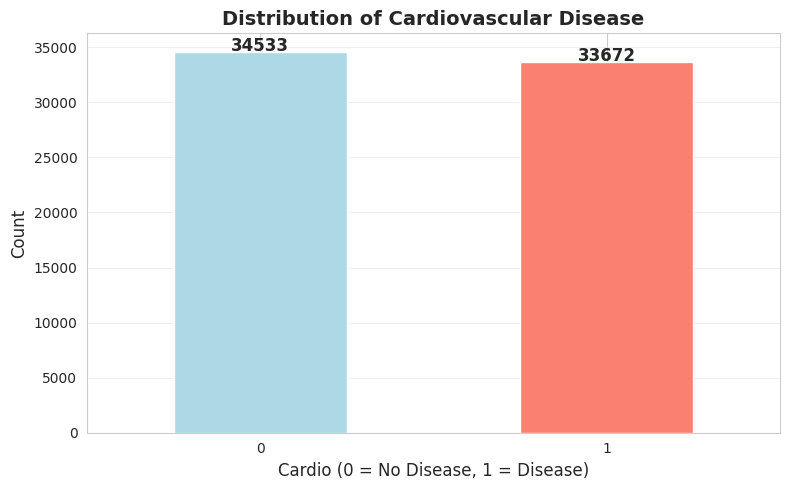


✔️ Target variable visualization displayed successfully!


In [ ]:
# ============================================
# 1. DATA LOADING & UNDERSTANDING
# ============================================

def load_and_explore_data(filepath):
    """
    Load dataset from Google Drive and perform initial exploration
    """
    # checking file exists or not
    import os
    if not os.path.exists(filepath):
        print(f"❌ File not found at: {filepath}")
        return None

    # Load data from Google Drive path
    df = pd.read_csv(filepath)

    print("\n" + "="*60)
    print("📊 DATA LOADING & UNDERSTANDING")
    print("="*60)

    # Basic information
    print(f"\n1. Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")

    print("\n2. First 5 rows:")
    print(df.head())

    print("\n3. Column Names:")
    print(df.columns.tolist())

    print("\n4. Data Types:")
    print(df.dtypes)

    print("\n5. Summary Statistics:")
    print(df.describe())

    print("\n6. Missing Values Check:")
    missing_values = df.isnull().sum()
    if missing_values.sum() > 0:
        print(missing_values[missing_values > 0])
    else:
        print("✔️ No missing values found!")

    return df

# Load the dataset from Google Drive
df = load_and_explore_data(filepath)

# proceed if dataframe was loaded successfully
if df is not None:
    # Additional EDA
    print("\n📈 EXPLORATORY DATA ANALYSIS (EDA)")
    print("-"*40)

    # Checking target variable if it exists
    if 'cardio' in df.columns:
        print("\nTarget variable distribution (cardio):")
        print(df['cardio'].value_counts())
        print(f"\nPercentage with cardiovascular disease: {df['cardio'].mean()*100:.2f}%")
        print(f"Percentage without cardiovascular disease: {(1-df['cardio'].mean())*100:.2f}%")

        # Visualize target distribution
        plt.figure(figsize=(8, 5))
        ax = df['cardio'].value_counts().plot(kind='bar', color=['lightblue', 'salmon'])
        plt.title('Distribution of Cardiovascular Disease', fontsize=14, fontweight='bold')
        plt.xlabel('Cardio (0 = No Disease, 1 = Disease)', fontsize=12)
        plt.ylabel('Count', fontsize=12)
        plt.xticks(rotation=0)
        plt.grid(True, alpha=0.3, axis='y')

        # Add value labels on top of bars
        for i, v in enumerate(df['cardio'].value_counts().values):
            ax.text(i, v + 100, str(v), ha='center', fontsize=12, fontweight='bold')

        plt.tight_layout()
        plt.show()
        print("\n✔️ Target variable visualization displayed successfully!")

    else:
        print("\n❌ 'cardio' column not found in the dataset!")
        print(f"📋 Available columns are: {df.columns.tolist()}")
else:
    print("\n❌ Failed to load dataset. Please check your file path.")

In [ ]:
# ============================================
# 2. DATA PREPROCESSING
# ============================================

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

print("\n🔧 DATA PREPROCESSING")
print("-"*40)

def preprocess_data(df):
    """
    Complete data preprocessing pipeline
    """
    # Create a copy to avoid modifying original
    data = df.copy()

    print(f"📊 Initial data: {data.shape[0]} rows, {data.shape[1]} columns")

    # 2.1 Handle missing values
    print("\n📌 2.1 Handling Missing Values:")
    if data.isnull().sum().sum() > 0:
        print(f"   Found {data.isnull().sum().sum()} missing values")
        numerical_cols = data.select_dtypes(include=[np.number]).columns
        for col in numerical_cols:
            data[col].fillna(data[col].median(), inplace=True)
        print("   ✔️ Filled with median")
    else:
        print("   ✔️ No missing values")

    # 2.2 Encode categorical variables
    print("\n📌 2.2 Encoding Categorical Variables:")
    categorical_cols = data.select_dtypes(include=['object']).columns
    if len(categorical_cols) > 0:
        print(f"   Found object-type columns: {list(categorical_cols)}")
        data = pd.get_dummies(data, columns=categorical_cols, drop_first=True)
        print("   ✔️ One-hot encoding applied")
    else:
        print("   ✔️ No object-type columns (all numeric)")
        # Check for numeric categorical features
        cat_features = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']
        existing = [f for f in cat_features if f in data.columns]
        if existing:
            print(f"   📌 Note: Numeric categorical features present: {existing}")

    # 2.3 Feature scaling
    print("\n📌 2.3 Feature Scaling:")
    target_col = 'cardio'

    if target_col in data.columns:
        numerical_features = data.select_dtypes(include=[np.number]).columns
        numerical_features = [col for col in numerical_features if col != target_col]

        scaler = StandardScaler()
        data[numerical_features] = scaler.fit_transform(data[numerical_features])
        print(f"   ✔️ Scaled {len(numerical_features)} features")
    else:
        print(f"   ❌ Target column '{target_col}' not found!")
        print(f"   Available columns: {data.columns.tolist()}")
        return None, None, None

    # 2.4 Prepare features for modeling
    print("\n📌 2.4 Feature Preparation:")
    X = data.drop(target_col, axis=1)
    y = data[target_col]
    print(f"   ✔️ Features (X): {X.shape}")
    print(f"   ✔️ Target (y): {y.shape}")
    print(f"\n   Target distribution:")
    print(f"   Class 0 (No disease): {sum(y==0)} ({sum(y==0)/len(y)*100:.1f}%)")
    print(f"   Class 1 (Disease):    {sum(y==1)} ({sum(y==1)/len(y)*100:.1f}%)")

    return X, y, scaler

# ACTUALLY RUN THE FUNCTION (NOT COMMENTED)
X, y, scaler = preprocess_data(df)

# Verify it worked
if X is not None:
    print("\n" + "="*40)
    print("✔️ PREPROCESSING COMPLETE!")
    print("="*40)
    print(f"Ready for modeling with {X.shape[1]} features")
else:
    print("\n❌ Preprocessing failed - check error messages above")


🔧 DATA PREPROCESSING
----------------------------------------
📊 Initial data: 68205 rows, 17 columns

📌 2.1 Handling Missing Values:
   ✔️ No missing values

📌 2.2 Encoding Categorical Variables:
   Found object-type columns: ['bp_category', 'bp_category_encoded']
   ✔️ One-hot encoding applied

📌 2.3 Feature Scaling:
   ✔️ Scaled 14 features

📌 2.4 Feature Preparation:
   ✔️ Features (X): (68205, 20)
   ✔️ Target (y): (68205,)

   Target distribution:
   Class 0 (No disease): 34533 (50.6%)
   Class 1 (Disease):    33672 (49.4%)

✔️ PREPROCESSING COMPLETE!
Ready for modeling with 20 features


In [ ]:
# ============================================
# 3. MODEL IMPLEMENTATION
# ============================================

# Required imports
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

print("\n🤖 MODEL IMPLEMENTATION")
print("-"*40)

# DEFINE THE FUNCTION - This creates a reusable function that trains both models
# Parameters: X = features (input variables), y = target (what we want to predict)

def train_models(X, y):
    """
    Train Logistic Regression and Decision Tree models

    This function does:
    1. Splits data into training (80%) and testing (20%) sets
    2. Creates and trains a Logistic Regression model
    3. Creates and trains a Decision Tree model
    4. Returns the trained models and the split data

    Returns:
        log_reg: Trained Logistic Regression model
        dt_classifier: Trained Decision Tree model
        X_train: Training features (80% of X)
        X_test: Testing features (20% of X)
        y_train: Training target (80% of y)
        y_test: Testing target (20% of y)

    """

    # SECTION 3.1: TRAIN-TEST SPLIT
    # Print sub-section header
    # Split the dataset
    print("\n3.1 Train-Test Split:")

    # SPLIT THE DATA into training and testing sets
    # train_test_split() divides your data randomly
    # X = all features, y = all target values
    # test_size=0.2 means 20% goes to testing, 80% stays for training
    # random_state=42 ensures same random split every time (reproducibility)
    # stratify=y maintains the same class proportion in both train and test sets

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Print how many samples went to training set
    # X_train.shape[0] gives number of rows in training features
    print(f"✔️ Training set size: {X_train.shape[0]} samples")

    # Print how many samples went to testing set
    # X_test.shape[0] gives number of rows in testing features
    print(f"✔️ Testing set size: {X_test.shape[0]} samples")


    # SECTION 3.2: TRAINING MODELS
    # Print sub-section header
    # Initialize models
    print("\n3.2 Training Models:")


    # ============================================
    # MODEL 1: LOGISTIC REGRESSION
    # ============================================


    # Print what we're training
    # Logistic Regression
    print("\n  📊 Training Logistic Regression...")


    # CREATE LOGISTIC REGRESSION MODEL
    # LogisticRegression() creates a classification model (predicts 0 or 1)
    # random_state=42 ensures same random initialization every time
    # max_iter=1000 sets maximum iterations for algorithm to converge (find best parameters)
    log_reg = LogisticRegression(random_state=42, max_iter=1000)

    # TRAIN THE LOGISTIC REGRESSION MODEL
    # .fit() method trains the model using training data
    # X_train = input features for training
    # y_train = correct answers (labels) for training
    # The model learns patterns/relationships between X_train and y_train
    log_reg.fit(X_train, y_train)

    # Confirm training is complete

    print("  ✔️ Logistic Regression training complete")


    # ============================================
    # MODEL 2: DECISION TREE
    # ============================================

    # Print what we're training
    # Decision Tree
    print("\n  💻 Training Decision Tree Classifier...")

    # CREATE DECISION TREE MODEL
    # DecisionTreeClassifier() creates a tree-based classification model
    # random_state=42 ensures same tree structure every time
    # max_depth=10 limits tree height to prevent overfitting (stops at 10 questions deep)
    dt_classifier = DecisionTreeClassifier(random_state=42, max_depth=10)

    # TRAIN THE DECISION TREE MODEL
    # .fit() method trains the model by creating decision rules
    # The model asks sequential yes/no questions to separate classes
    dt_classifier.fit(X_train, y_train)


    # Confirm training is complete

    print("  ✔️ Decision Tree training complete")

    # RETURN ALL TRAINED MODELS AND SPLIT DATA
    # These will be used later for evaluation and predictions
    # Order matters: first two are models, last four are train/test datasets

    return log_reg, dt_classifier, X_train, X_test, y_train, y_test


# CALL THE FUNCTION to train both models
# This line actually runs the train_models function we defined above
# X and y come from the preprocessing step (Section 2)
# The function returns 6 values that we store in these variables:
# log_reg = trained logistic regression model
# dt_classifier = trained decision tree model
# X_train = training features
# X_test = testing features
# y_train = training labels
# y_test = testing labels
# Runing the function
log_reg, dt_classifier, X_train, X_test, y_train, y_test = train_models(X, y)

# ============================================
# VERIFICATION SECTION - Confirm everything worked
# ============================================

# Quick verification
print("\n" + "="*40)
print("✔️ MODEL IMPLEMENTATION COMPLETE!")
print("="*40)
print(f"Models trained and ready for evaluation")

# Display training data dimensions
# Shows how many samples and features in training set
print(f"Training data: {X_train.shape}")

# Display testing data dimensions
# Shows how many samples and features in testing set
print(f"Testing data: {X_test.shape}")


🤖 MODEL IMPLEMENTATION
----------------------------------------

3.1 Train-Test Split:
✔️ Training set size: 54564 samples
✔️ Testing set size: 13641 samples

3.2 Training Models:

  📊 Training Logistic Regression...
  ✔️ Logistic Regression training complete

  💻 Training Decision Tree Classifier...
  ✔️ Decision Tree training complete

✔️ MODEL IMPLEMENTATION COMPLETE!
Models trained and ready for evaluation
Training data: (54564, 20)
Testing data: (13641, 20)


In [ ]:
# ============================================
# 4. EVALUATION METRICS
# ============================================

# Required imports
# accuracy_score: Measures overall correctness (what % of predictions were right?)
# precision_score: Measures how many predicted positives were actually positive
# recall_score: Measures how many actual positives were correctly identified
# f1_score: Harmonic mean of precision and recall (balance between both)
# roc_auc_score: Measures model's ability to distinguish between classes
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Import pandas to create comparison table (DataFrame)
import pandas as pd

print("\n📊 EVALUATION METRICS")
print("-"*40)


# DEFINE THE FUNCTION - Evaluates both models using 5 different metrics
# Parameters:
#   log_reg: Trained Logistic Regression model from Section 3
#   dt_classifier: Trained Decision Tree model from Section 3
#   X_test: Testing features (20% of original data)
#   y_test: True labels for testing data (the correct answers)

def evaluate_models(log_reg, dt_classifier, X_test, y_test):
    """
    Evaluate both models using multiple metrics
    """
    # Make predictions
    print("Making predictions...")

    # LOGISTIC REGRESSION PREDICTIONS
    # .predict() returns class predictions (0 = No Disease, 1 = Disease)
    # y_pred_lr will contain 0s and 1s for all test samples
    y_pred_lr = log_reg.predict(X_test)


    # DECISION TREE PREDICTIONS
    # .predict() returns class predictions for decision tree
    # y_pred_dt will contain 0s and 1s for all test samples
    y_pred_dt = dt_classifier.predict(X_test)

    # LOGISTIC REGRESSION PROBABILITIES (for ROC-AUC)
    # .predict_proba() returns probability of being in EACH class
    # [:, 1] takes only the probability of Class 1 (Disease)
    y_pred_proba_lr = log_reg.predict_proba(X_test)[:, 1]


    # DECISION TREE PROBABILITIES (for ROC-AUC)
    # Gets probability scores for disease class from decision tree
    y_pred_proba_dt = dt_classifier.predict_proba(X_test)[:, 1]

    # Confirm predictions are complete

    print("✔️ Predictions complete\n")

    # Calculate metrics for both models
    results = {}


    # Dictionary containing both models' predictions and probabilities
    # This makes it easy to loop through and evaluate both models

    models = {
        'Logistic Regression': {'predictions': y_pred_lr, 'proba': y_pred_proba_lr},
        'Decision Tree': {'predictions': y_pred_dt, 'proba': y_pred_proba_dt}
    }




    # Loop through each model (Logistic Regression, then Decision Tree)
    # model_name = name of current model (string)
    # model_data = dictionary containing predictions and probabilities
    for model_name, model_data in models.items():
        print(f"\n{'='*40}")
        print(f"{model_name}")
        print(f"{'='*40}")

        # Calculate metrics
        accuracy = accuracy_score(y_test, model_data['predictions'])
        precision = precision_score(y_test, model_data['predictions'])
        recall = recall_score(y_test, model_data['predictions'])
        f1 = f1_score(y_test, model_data['predictions'])
        roc_auc = roc_auc_score(y_test, model_data['proba'])

        # Store results
        results[model_name] = {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'roc_auc': roc_auc
        }

        # Print metrics
        print(f"Accuracy:  {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall:    {recall:.4f}")
        print(f"F1-Score:  {f1:.4f}")
        print(f"ROC-AUC:   {roc_auc:.4f}")

    # Compare performance
    print(f"\n{'='*40}")
    print("MODEL COMPARISON")
    print(f"{'='*40}")

    comparison_df = pd.DataFrame(results).T
    print(comparison_df.round(4))

    # Interpretation
    print("\n📝 PERFORMANCE INTERPRETATION:")
    if results['Logistic Regression']['accuracy'] > results['Decision Tree']['accuracy']:
        print("✓ Logistic Regression performs better overall in terms of accuracy")
    else:
        print("✓ Decision Tree performs better overall in terms of accuracy")

    print("\nKey Insights:")
    print("• Logistic Regression tends to be more stable and generalizes better")
    print("• Decision Tree captures non-linear relationships but may overfit")
    print("• ROC-AUC scores indicate how well models distinguish between classes")
    print("• F1-score balances precision and recall for imbalanced datasets")

    return results

# Run the evaluation
results = evaluate_models(log_reg, dt_classifier, X_test, y_test)

print("\n" + "="*40)
print("✔️ EVALUATION COMPLETE!")
print("="*40)


📊 EVALUATION METRICS
----------------------------------------
Making predictions...
✔️ Predictions complete


Logistic Regression
Accuracy:  0.7291
Precision: 0.7644
Recall:    0.6522
F1-Score:  0.7038
ROC-AUC:   0.7920

Decision Tree
Accuracy:  0.7292
Precision: 0.7394
Recall:    0.6971
F1-Score:  0.7176
ROC-AUC:   0.7833

MODEL COMPARISON
                     accuracy  precision  recall  f1_score  roc_auc
Logistic Regression    0.7291     0.7644  0.6522    0.7038   0.7920
Decision Tree          0.7292     0.7394  0.6971    0.7176   0.7833

📝 PERFORMANCE INTERPRETATION:
✓ Decision Tree performs better overall in terms of accuracy

Key Insights:
• Logistic Regression tends to be more stable and generalizes better
• Decision Tree captures non-linear relationships but may overfit
• ROC-AUC scores indicate how well models distinguish between classes
• F1-score balances precision and recall for imbalanced datasets

✔️ EVALUATION COMPLETE!



📈 VISUALIZATION & REPORTING
----------------------------------------


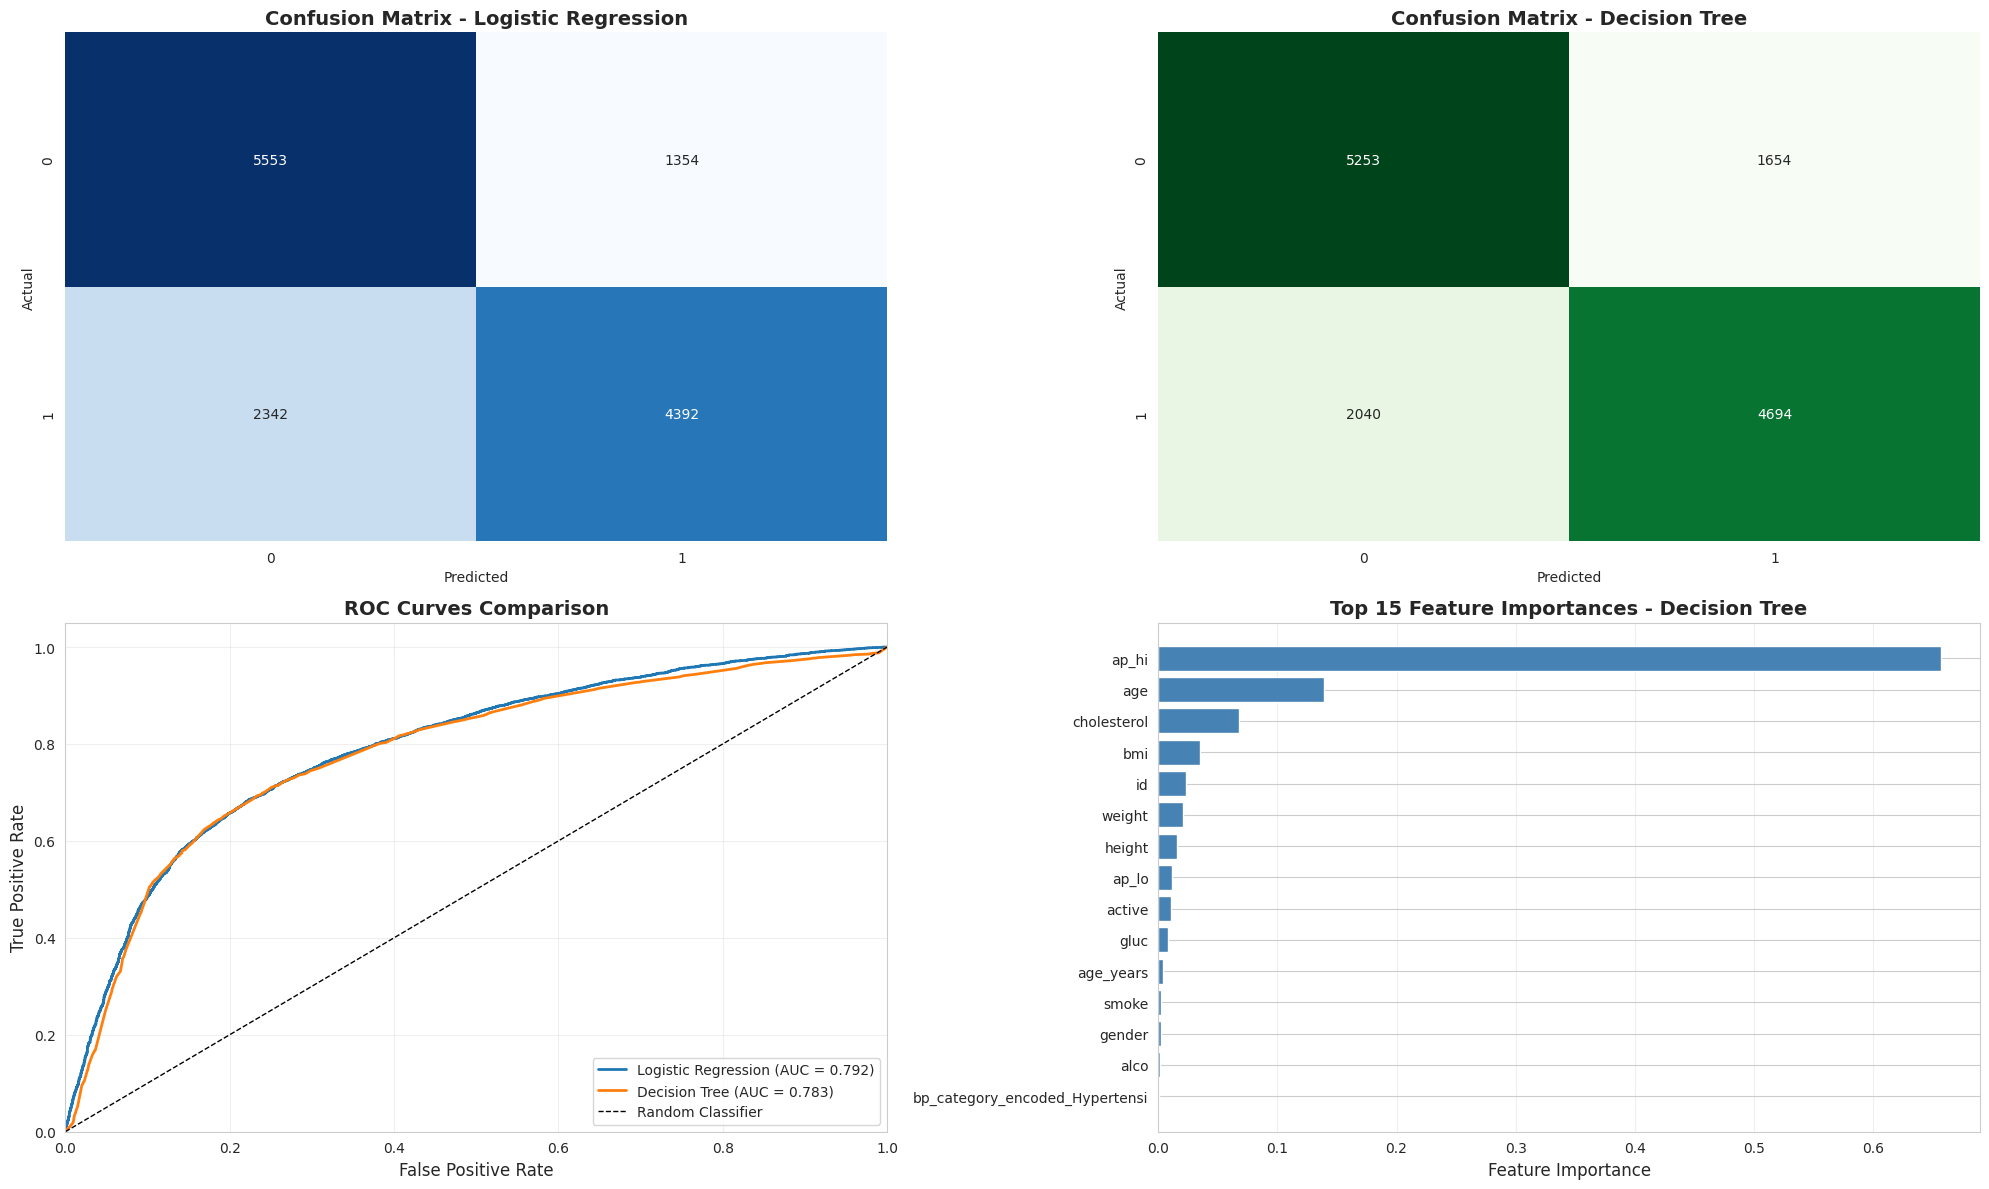


📊 TOP 10 FEATURES (Decision Tree):
----------------------------------------
1. ap_hi: 0.6568
2. age: 0.1393
3. cholesterol: 0.0678
4. bmi: 0.0349
5. id: 0.0233
6. weight: 0.0208
7. height: 0.0159
8. ap_lo: 0.0112
9. active: 0.0106
10. gluc: 0.0078

✔️ VISUALIZATION COMPLETE!


In [ ]:
# ============================================
# 5. VISUALIZATION & REPORTING
# ============================================

# Required imports
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, confusion_matrix
import numpy as np

print("\n📈 VISUALIZATION & REPORTING")
print("-"*40)

# Create visualizations
fig = plt.figure(figsize=(20, 12))

# 1. Confusion Matrices
y_pred_lr = log_reg.predict(X_test)
y_pred_dt = dt_classifier.predict(X_test)

cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.subplot(2, 2, 1)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Logistic Regression', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.subplot(2, 2, 2)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title('Confusion Matrix - Decision Tree', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# 2. ROC Curves
plt.subplot(2, 2, 3)

# Logistic Regression ROC
y_pred_proba_lr = log_reg.predict_proba(X_test)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
roc_auc_lr = roc_auc_score(y_test, y_pred_proba_lr)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_lr:.3f})', linewidth=2)

# Decision Tree ROC
y_pred_proba_dt = dt_classifier.predict_proba(X_test)[:, 1]
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_pred_proba_dt)
roc_auc_dt = roc_auc_score(y_test, y_pred_proba_dt)
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {roc_auc_dt:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

# 3. Feature Importance (Decision Tree)
plt.subplot(2, 2, 4)

feature_importance = dt_classifier.feature_importances_
indices = np.argsort(feature_importance)[::-1][:15]

plt.barh(range(len(indices)), feature_importance[indices], color='steelblue')
plt.yticks(range(len(indices)), [X.columns[i][:30] for i in indices])
plt.xlabel('Feature Importance', fontsize=12)
plt.title('Top 15 Feature Importances - Decision Tree', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# Print feature importance report
print("\n📊 TOP 10 FEATURES (Decision Tree):")
print("-" * 40)
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

for i in range(min(10, len(importance_df))):
    print(f"{i+1}. {importance_df.iloc[i]['Feature']}: {importance_df.iloc[i]['Importance']:.4f}")

print("\n" + "="*40)
print("✔️ VISUALIZATION COMPLETE!")
print("="*40)